In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from iertools.read import read_sql

In [2]:
f = "../osm/005_measures_techos/run/eplusout.sql"
casa = read_sql(f,alias=True)

In [3]:
sc = casa.construction_systems
casa.get_construction(sc)



Construction system:CAD15CMA0P7
Total thickness    :0.15 m
Total layers:[1]
InsideAbsorpVis:[0.7]
OutsideAbsorpVis:[0.7]
OutsideAbsorpSolar:[0.7]
InsideAbsorpThermal:[0.9]
OutsideRoughness:[2]


,NameMaterial,Conductivity,Density,SpecHeat,Thickness
0,CAD15cma0p7,1.73,2300.0,880.0,0.15








Construction system:LADRILLO14CM0P7
Total thickness    :0.14 m
Total layers:[1]
InsideAbsorpVis:[0.7]
OutsideAbsorpVis:[0.7]
OutsideAbsorpSolar:[0.7]
InsideAbsorpThermal:[0.9]
OutsideRoughness:[4]


,NameMaterial,Conductivity,Density,SpecHeat,Thickness
1,Ladrillo14cm0p7,0.81,1800.0,880.0,0.14








Construction system:MURO_EXT
Total thickness    :0.16 m
Total layers:[2]
InsideAbsorpVis:[0.7]
OutsideAbsorpVis:[0.7]
OutsideAbsorpSolar:[0.7]
InsideAbsorpThermal:[0.9]
OutsideRoughness:[2]


,NameMaterial,Conductivity,Density,SpecHeat,Thickness
3,Repellado2cma0p7,0.72,1860.0,840.0,0.02
2,Ladrillo14cm0p7,0.81,1800.0,880.0,0.14


In [4]:
data_casa = casa.data
data_casa

variable_name,Ti_ESTE,Id,Ib,To,Ti_OESTE,TECHO_ESTE:Surface Outside Face Incident Solar Radiation Rate per Area (W/m2),TECHO_OESTE:Surface Outside Face Incident Solar Radiation Rate per Area (W/m2)
date,,,,,,,
2006-01-01 00:10:00,25.597587,0.0,0.0,13.766667,25.661020,0.0,0.0
2006-01-01 00:20:00,25.471299,0.0,0.0,13.933333,25.536126,0.0,0.0
2006-01-01 00:30:00,25.345739,0.0,0.0,14.100000,25.412097,0.0,0.0
2006-01-01 00:40:00,25.221431,0.0,0.0,14.266667,25.288799,0.0,0.0
2006-01-01 00:50:00,25.098625,0.0,0.0,14.433333,25.166221,0.0,0.0
...,...,...,...,...,...,...,...
2006-12-31 23:20:00,28.034176,0.0,0.0,16.666667,27.787962,0.0,0.0
2006-12-31 23:30:00,27.893976,0.0,0.0,16.550000,27.650927,0.0,0.0
2006-12-31 23:40:00,27.756378,0.0,0.0,16.433333,27.522416,0.0,0.0


In [5]:
data_casa.To.resample("D").mean().idxmax()

Timestamp('2006-05-16 00:00:00')

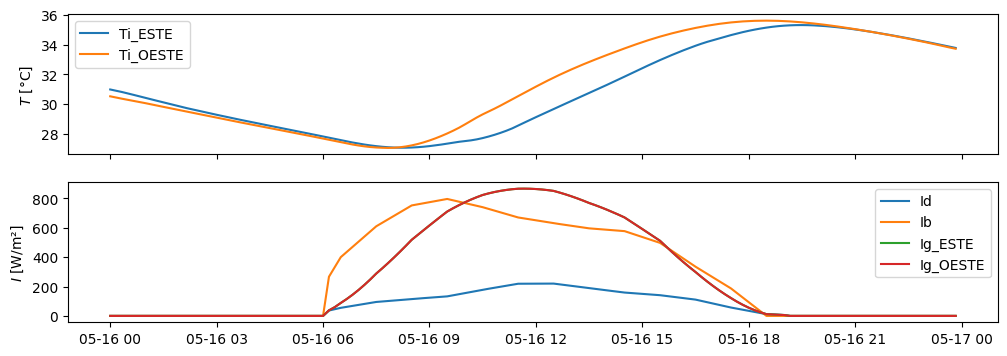

In [9]:
fig, ax = plt.subplots(2,1, figsize=(12,4),sharex=True)

ax[0].plot(data_casa.Ti_ESTE["2006-05-16"],label="Ti_ESTE")
ax[0].plot(data_casa.Ti_OESTE["2006-05-16"],label="Ti_OESTE")
ax[0].set_ylabel("$T$ [°C]")

ax[1].plot(data_casa.Id["2006-05-16"],label="Id")
ax[1].plot(data_casa.Ib["2006-05-16"],label="Ib")
ax[1].plot(data_casa.loc["2006-05-16","TECHO_ESTE:Surface Outside Face Incident Solar Radiation Rate per Area (W/m2)"],label="Ig_ESTE")
ax[1].plot(data_casa.loc["2006-05-16","TECHO_OESTE:Surface Outside Face Incident Solar Radiation Rate per Area (W/m2)"],label="Ig_OESTE")
ax[1].set_ylabel("$I$ [W/m$²$]")

ax[0].legend()
ax[1].legend()

plt.set_xlabel("")